<a href="https://colab.research.google.com/github/durvanshi/NNDL/blob/main/NNDL_practical03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8185 - loss: 0.5159 - val_accuracy: 0.8321 - val_loss: 0.4667
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8621 - loss: 0.3854 - val_accuracy: 0.8501 - val_loss: 0.4215
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8745 - loss: 0.3451 - val_accuracy: 0.8721 - val_loss: 0.3557
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3177 - val_accuracy: 0.8758 - val_loss: 0.3389
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8914 - loss: 0.2997 - val_accuracy: 0.8777 - val_loss: 0.3382
Epoch 6

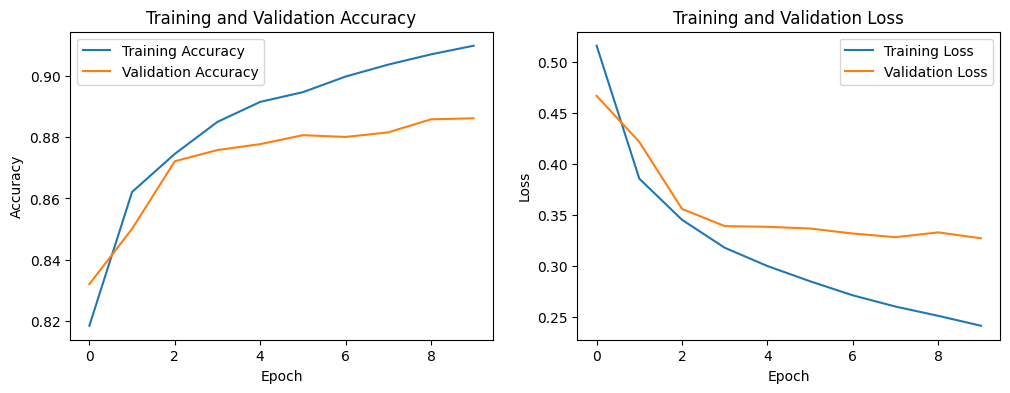

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


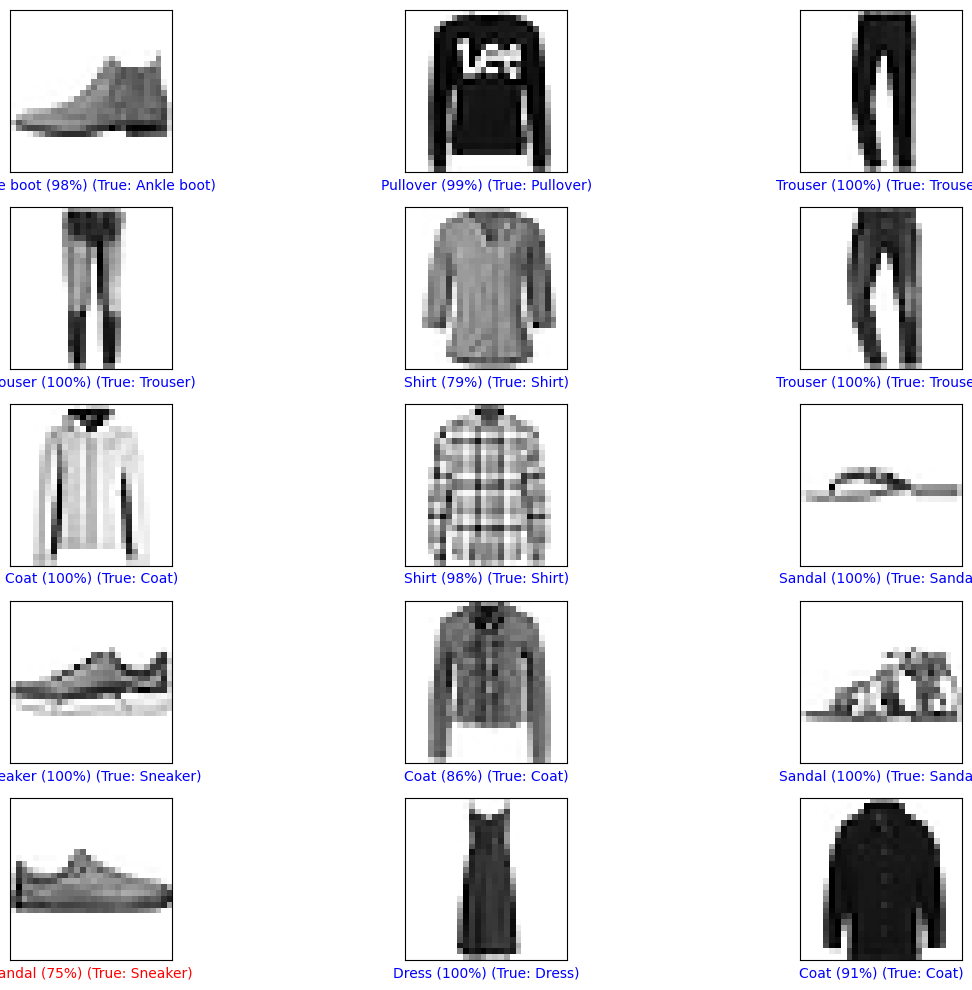

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images to a 1D vector for a Feed Forward Neural Network
# Each image is 28x28 pixels, so we flatten it to 784 features
train_images_flat = train_images.reshape(-1, 28 * 28)
test_images_flat = test_images.reshape(-1, 28 * 28)

# Define class names for plotting
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Training images shape: {train_images_flat.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images_flat.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Define the model (missing in original code)
model = keras.Sequential([
    keras.layers.Input(shape=(784,)), # Input layer for flattened images
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compile the model (metrics was isolated in original code)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_images_flat, train_labels, epochs=10, validation_split=0.2
)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(
    test_images_flat, test_labels, verbose=2
)

print(f"\nTest accuracy: {test_accuracy}")

# Plot training history
plt.figure(figsize=(12, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Make predictions on the test dataset
predictions = model.predict(test_images_flat)

# Function to plot image, true label, and predicted label
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(
        f"{class_names[predicted_label]} "
        f"({100 * np.max(predictions_array):.0f}%) " # Corrected format specifier
        f"(True: {class_names[true_label]})", color=color
    )

# Plot the first 15 test images with predictions
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions[i], test_labels, test_images) # Pass original 2D test_images for plotting

plt.tight_layout()
plt.show()